# Walmart Store Sales — Prophet baseline

This notebook trains a classical statistical time-series baseline with Prophet.

Main choices:

- validation is the last `39` weeks of `train.csv`, matching the Kaggle test horizon;
- metric is Kaggle-style WMAE, with holiday rows weighted by `5`;
- one Prophet model is fitted per `(Store, Dept)` time series;
- because Prophet is much slower than one global ML model, the default baseline uses the top `300` highest-volume Store-Dept series;
- every run logs metrics, predictions, plots, and artifacts to W&B;
- no MLflow is used.

Increase `CONFIG["top_n_series"]` only after the baseline runs successfully in Colab.


In [1]:
%pip install -q "prophet>=1.1,<2" "wandb>=0.19,<1" "pandas>=2.2,<3" "numpy>=1.26,<3" "matplotlib>=3.8,<4" "scikit-learn>=1.4,<2"


In [2]:
from __future__ import annotations

import json
import logging
import os
import platform
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import wandb
from prophet import Prophet

warnings.filterwarnings("ignore")
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
logging.getLogger("prophet").setLevel(logging.WARNING)

pd.set_option("display.max_columns", 120)
print({
    "python": platform.python_version(),
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "wandb": wandb.__version__,
})


{'python': '3.12.13', 'pandas': '2.2.2', 'numpy': '2.0.2', 'wandb': '0.28.0'}


In [3]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as exc:
    print(f"Not running in Colab or Drive unavailable: {exc}")


Mounted at /content/drive


## Configuration

Prophet is a per-series model. The default `top_n_series=300` keeps the baseline Colab-friendly. Set it to a larger number only when you intentionally want a slower run.


In [4]:
SEED = 42
np.random.seed(SEED)

CONFIG = {
    "seed": SEED,
    "validation_weeks": 39,
    "holiday_weight": 5.0,
    "top_n_series": 300,
    "min_history_points": 52,
    "growth": "linear",
    "yearly_seasonality": True,
    "weekly_seasonality": False,
    "daily_seasonality": False,
    "seasonality_mode": "additive",
    "changepoint_prior_scale": 0.05,
    "seasonality_prior_scale": 10.0,
    "holidays_prior_scale": 10.0,
    "interval_width": 0.80,
    "prediction_clip_min": 0.0,
    "prediction_clip_max": 300000.0,
    "run_final_refit": False,
    "wandb_project": "Walmart-Recruiting---Store-Sales-Forecasting",
    "wandb_entity": "kende23-n-a",
    "wandb_group": "prophet-baseline",
    "run_name": "prophet_baseline_top300_validation",
    "artifact_name": "prophet-baseline-top300-validation",
}

DATA_DIR = Path("/content/drive/MyDrive/walmart_competition_data")
OUTPUT_DIR = Path("/content/artifacts/prophet_baseline")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG


{'seed': 42,
 'validation_weeks': 39,
 'holiday_weight': 5.0,
 'top_n_series': 300,
 'min_history_points': 52,
 'growth': 'linear',
 'yearly_seasonality': True,
 'weekly_seasonality': False,
 'daily_seasonality': False,
 'seasonality_mode': 'additive',
 'changepoint_prior_scale': 0.05,
 'seasonality_prior_scale': 10.0,
 'holidays_prior_scale': 10.0,
 'interval_width': 0.8,
 'prediction_clip_min': 0.0,
 'prediction_clip_max': 300000.0,
 'run_final_refit': False,
 'wandb_project': 'Walmart-Recruiting---Store-Sales-Forecasting',
 'wandb_entity': 'kende23-n-a',
 'wandb_group': 'prophet-baseline',
 'run_name': 'prophet_baseline_top300_validation',
 'artifact_name': 'prophet-baseline-top300-validation'}

## Load data


In [5]:
required_files = ["train.csv", "test.csv", "features.csv", "stores.csv"]
missing_files = [name for name in required_files if not (DATA_DIR / name).exists()]
if missing_files:
    raise FileNotFoundError({"data_dir": str(DATA_DIR), "missing_files": missing_files})

train_raw = pd.read_csv(DATA_DIR / "train.csv", parse_dates=["Date"])
test_raw = pd.read_csv(DATA_DIR / "test.csv", parse_dates=["Date"])
features_raw = pd.read_csv(DATA_DIR / "features.csv", parse_dates=["Date"])
stores_raw = pd.read_csv(DATA_DIR / "stores.csv")

required_train = {"Store", "Dept", "Date", "Weekly_Sales", "IsHoliday"}
required_test = {"Store", "Dept", "Date", "IsHoliday"}
missing = {
    "train": sorted(required_train.difference(train_raw.columns)),
    "test": sorted(required_test.difference(test_raw.columns)),
}
if any(missing.values()):
    raise ValueError(missing)

train_raw = train_raw.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)
test_raw = test_raw.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)

profile = pd.DataFrame({
    "table": ["train", "test", "features", "stores"],
    "rows": [len(train_raw), len(test_raw), len(features_raw), len(stores_raw)],
    "columns": [train_raw.shape[1], test_raw.shape[1], features_raw.shape[1], stores_raw.shape[1]],
    "min_date": [train_raw.Date.min(), test_raw.Date.min(), features_raw.Date.min(), pd.NaT],
    "max_date": [train_raw.Date.max(), test_raw.Date.max(), features_raw.Date.max(), pd.NaT],
})
display(profile)
display(train_raw.head())


,table,rows,columns,min_date,max_date
0,train,421570,5,2010-02-05,2012-10-26
1,test,115064,4,2012-11-02,2013-07-26
2,features,8190,12,2010-02-05,2013-07-26
3,stores,45,3,NaT,NaT


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


## Split and top-series selection


In [6]:
all_train_dates = pd.Index(sorted(train_raw["Date"].unique()), name="Date")
test_dates = pd.Index(sorted(test_raw["Date"].unique()), name="Date")
val_dates = all_train_dates[-CONFIG["validation_weeks"]:]
fit_dates = all_train_dates[:-CONFIG["validation_weeks"]]

if len(test_dates) != CONFIG["validation_weeks"]:
    raise ValueError(f"Expected test horizon {CONFIG['validation_weeks']}, got {len(test_dates)}")
if len(fit_dates) < CONFIG["min_history_points"]:
    raise ValueError("Not enough fit history for configured Prophet baseline.")

top_series = (
    train_raw.groupby(["Store", "Dept"], as_index=False)["Weekly_Sales"]
    .sum()
    .sort_values("Weekly_Sales", ascending=False)
    .head(CONFIG["top_n_series"])[["Store", "Dept"]]
)
selected_keys = set(map(tuple, top_series[["Store", "Dept"]].to_numpy()))
selected_train = train_raw.merge(top_series.assign(_keep=1), on=["Store", "Dept"], how="inner").drop(columns="_keep")

split_summary = {
    "validation_weeks": CONFIG["validation_weeks"],
    "fit_start": str(fit_dates.min().date()),
    "fit_end": str(fit_dates.max().date()),
    "validation_start": str(val_dates.min().date()),
    "validation_end": str(val_dates.max().date()),
    "test_start": str(test_dates.min().date()),
    "test_end": str(test_dates.max().date()),
    "all_train_rows": int(len(train_raw)),
    "selected_train_rows": int(len(selected_train)),
    "top_n_series": int(CONFIG["top_n_series"]),
    "selected_series": int(len(selected_keys)),
}
display(pd.Series(split_summary, name="value").to_frame())


,value
validation_weeks,39
fit_start,2010-02-05
fit_end,2012-01-27
validation_start,2012-02-03
validation_end,2012-10-26
test_start,2012-11-02
test_end,2013-07-26
all_train_rows,421570
selected_train_rows,42900
top_n_series,300


## Metric and baseline helpers


In [7]:
def wmae(y_true, y_pred, is_holiday, holiday_weight: float = 5.0) -> float:
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    weights = np.where(np.asarray(is_holiday, dtype=bool), holiday_weight, 1.0)
    return float(np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights))


def make_holidays_frame(dates: pd.Series, is_holiday: pd.Series) -> pd.DataFrame:
    holidays = pd.DataFrame({
        "ds": pd.to_datetime(dates),
        "is_holiday": np.asarray(is_holiday, dtype=bool),
    })
    holidays = holidays.loc[holidays["is_holiday"], ["ds"]].drop_duplicates()
    holidays["holiday"] = "walmart_holiday"
    return holidays[["holiday", "ds"]]

holiday_calendar = pd.concat([
    train_raw[["Date", "IsHoliday"]].rename(columns={"Date": "ds"}),
    test_raw[["Date", "IsHoliday"]].rename(columns={"Date": "ds"}),
], ignore_index=True).drop_duplicates("ds")
holidays_df = make_holidays_frame(holiday_calendar["ds"], holiday_calendar["IsHoliday"])

holiday_by_date = (
    train_raw[["Date", "IsHoliday"]]
    .drop_duplicates("Date")
    .set_index("Date")
    .reindex(all_train_dates)["IsHoliday"]
    .fillna(False)
    .astype(bool)
)

sales_panel = (
    selected_train.pivot_table(index=["Store", "Dept"], columns="Date", values="Weekly_Sales", aggfunc="sum")
    .reindex(index=pd.MultiIndex.from_frame(top_series), columns=all_train_dates)
    .fillna(0.0)
    .sort_index()
)

actual_val = sales_panel.loc[:, val_dates].to_numpy(dtype=float)
seasonal_naive = sales_panel.loc[:, all_train_dates[-CONFIG["validation_weeks"] - 52:-52]].to_numpy(dtype=float)
val_holidays_matrix = np.tile(holiday_by_date.loc[val_dates].to_numpy(dtype=bool), (sales_panel.shape[0], 1))
seasonal_naive_wmae = wmae(actual_val.ravel(), seasonal_naive.ravel(), val_holidays_matrix.ravel(), CONFIG["holiday_weight"])

print({
    "selected_series": len(sales_panel),
    "seasonal_naive_wmae": seasonal_naive_wmae,
    "holiday_dates_known": len(holidays_df),
})
display(holidays_df.head())


{'selected_series': 300, 'seasonal_naive_wmae': 6026.290685815602, 'holiday_dates_known': 13}


,holiday,ds
1,walmart_holiday,2010-02-12
31,walmart_holiday,2010-09-10
42,walmart_holiday,2010-11-26
47,walmart_holiday,2010-12-31
53,walmart_holiday,2011-02-11


## Fit one Prophet model per selected Store-Dept series

For short/sparse/problematic series, the notebook falls back to the same 52-week seasonal naive value. This keeps the baseline robust and makes failures visible in W&B.


In [8]:
def fit_predict_prophet_for_series(store: int, dept: int, series: pd.Series) -> tuple[pd.DataFrame, dict]:
    history = series.loc[fit_dates].reset_index()
    history.columns = ["ds", "y"]
    history["y"] = history["y"].astype(float).clip(lower=0.0)

    actual = series.loc[val_dates].astype(float).to_numpy()
    seasonal_fallback = series.loc[all_train_dates[-CONFIG["validation_weeks"] - 52:-52]].astype(float).to_numpy()

    info = {
        "Store": int(store),
        "Dept": int(dept),
        "status": "fit",
        "history_points": int(len(history)),
        "nonzero_history_points": int((history["y"] != 0).sum()),
        "error": "",
    }

    if len(history) < CONFIG["min_history_points"] or info["nonzero_history_points"] < 2:
        pred = seasonal_fallback.copy()
        info["status"] = "fallback_insufficient_history"
    else:
        try:
            model = Prophet(
                growth=CONFIG["growth"],
                yearly_seasonality=CONFIG["yearly_seasonality"],
                weekly_seasonality=CONFIG["weekly_seasonality"],
                daily_seasonality=CONFIG["daily_seasonality"],
                seasonality_mode=CONFIG["seasonality_mode"],
                changepoint_prior_scale=CONFIG["changepoint_prior_scale"],
                seasonality_prior_scale=CONFIG["seasonality_prior_scale"],
                holidays_prior_scale=CONFIG["holidays_prior_scale"],
                interval_width=CONFIG["interval_width"],
                holidays=holidays_df,
            )
            model.fit(history)
            future = pd.DataFrame({"ds": val_dates})
            forecast = model.predict(future)
            pred = forecast["yhat"].to_numpy(dtype=float)
            pred = np.nan_to_num(pred, nan=0.0, posinf=CONFIG["prediction_clip_max"], neginf=0.0)
            pred = np.clip(pred, CONFIG["prediction_clip_min"], CONFIG["prediction_clip_max"])
        except Exception as exc:
            pred = seasonal_fallback.copy()
            info["status"] = "fallback_fit_error"
            info["error"] = repr(exc)[:300]

    records = pd.DataFrame({
        "Store": int(store),
        "Dept": int(dept),
        "Date": pd.to_datetime(val_dates),
        "IsHoliday": holiday_by_date.loc[val_dates].to_numpy(dtype=bool),
        "Weekly_Sales": actual,
        "SeasonalNaive52": seasonal_fallback,
        "Prediction": pred,
        "AbsError": np.abs(actual - pred),
        "ModelStatus": info["status"],
    })
    return records, info

start_time = time.time()
all_predictions = []
series_infos = []

for idx, ((store, dept), row) in enumerate(sales_panel.iterrows(), start=1):
    pred_df, info = fit_predict_prophet_for_series(int(store), int(dept), row)
    all_predictions.append(pred_df)
    series_infos.append(info)
    if idx % 25 == 0 or idx == len(sales_panel):
        elapsed = time.time() - start_time
        print({"finished_series": idx, "total_series": len(sales_panel), "elapsed_min": round(elapsed / 60, 2)})

val_pred_df = pd.concat(all_predictions, ignore_index=True)
series_info_df = pd.DataFrame(series_infos)

prophet_wmae = wmae(val_pred_df["Weekly_Sales"], val_pred_df["Prediction"], val_pred_df["IsHoliday"], CONFIG["holiday_weight"])
prophet_mae = float(np.mean(np.abs(val_pred_df["Weekly_Sales"] - val_pred_df["Prediction"])))
improvement_vs_seasonal = 100.0 * (seasonal_naive_wmae - prophet_wmae) / seasonal_naive_wmae

metrics = {
    "validation/wmae": float(prophet_wmae),
    "validation/mae": float(prophet_mae),
    "validation/seasonal_naive_wmae": float(seasonal_naive_wmae),
    "validation/improvement_vs_seasonal_naive_pct": float(improvement_vs_seasonal),
    "fit/series_total": int(len(series_info_df)),
    "fit/series_fit_ok": int((series_info_df["status"] == "fit").sum()),
    "fit/series_fallback": int((series_info_df["status"] != "fit").sum()),
    "fit/elapsed_minutes": float((time.time() - start_time) / 60),
}
print(metrics)
display(series_info_df["status"].value_counts().rename_axis("status").reset_index(name="count"))
display(val_pred_df.head())


{'finished_series': 25, 'total_series': 300, 'elapsed_min': 0.12}
{'finished_series': 50, 'total_series': 300, 'elapsed_min': 0.18}
{'finished_series': 75, 'total_series': 300, 'elapsed_min': 0.23}
{'finished_series': 100, 'total_series': 300, 'elapsed_min': 0.28}
{'finished_series': 125, 'total_series': 300, 'elapsed_min': 0.34}
{'finished_series': 150, 'total_series': 300, 'elapsed_min': 0.41}
{'finished_series': 175, 'total_series': 300, 'elapsed_min': 0.46}
{'finished_series': 200, 'total_series': 300, 'elapsed_min': 0.51}
{'finished_series': 225, 'total_series': 300, 'elapsed_min': 0.56}
{'finished_series': 250, 'total_series': 300, 'elapsed_min': 0.63}
{'finished_series': 275, 'total_series': 300, 'elapsed_min': 0.68}
{'finished_series': 300, 'total_series': 300, 'elapsed_min': 0.73}
{'validation/wmae': 6455.664630896183, 'validation/mae': 5940.075194914438, 'validation/seasonal_naive_wmae': 6026.290685815602, 'validation/improvement_vs_seasonal_naive_pct': -7.125012175254351, 'f

,status,count
0,fit,300


,Store,Dept,Date,IsHoliday,Weekly_Sales,SeasonalNaive52,Prediction,AbsError,ModelStatus
0,1,2,2012-02-03,False,54322.24,46829.12,47815.690351,6506.549649,fit
1,1,2,2012-02-10,True,50581.06,47595.35,45730.088782,4850.971218,fit
2,1,2,2012-02-17,False,46085.47,49202.06,49463.201240,3377.731240,fit
3,1,2,2012-02-24,False,47080.12,46165.25,48967.755554,1887.635554,fit
4,1,2,2012-03-02,False,52608.51,53035.54,48329.200888,4279.309112,fit


## Diagnostics and W&B logging


wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: kende23 (kende23-n-a) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


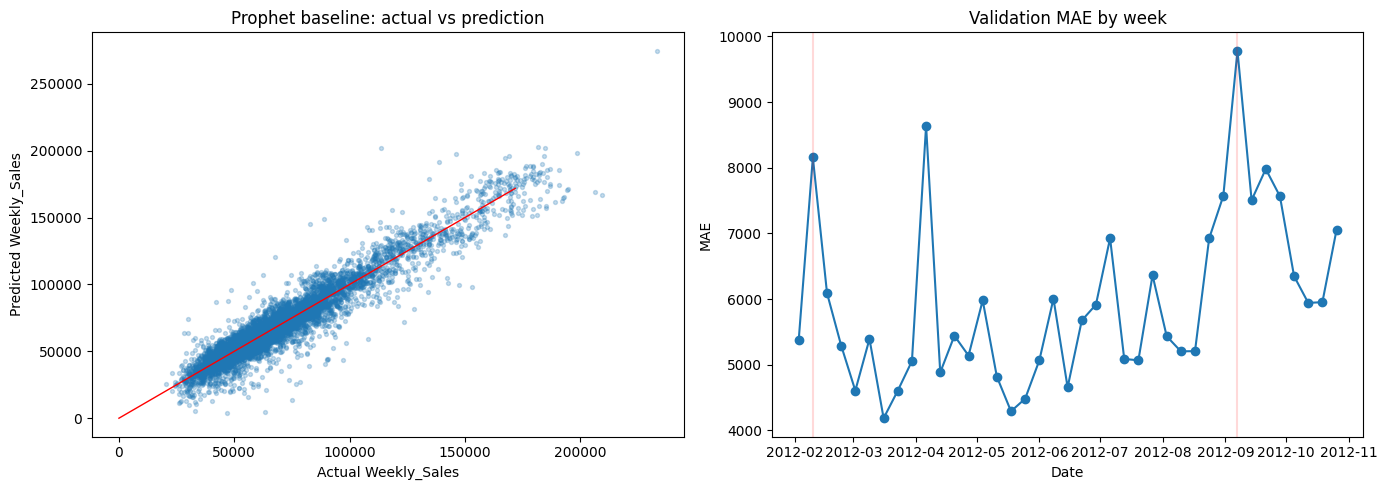

{'validation/wmae': 6455.664630896183,
 'validation/mae': 5940.075194914438,
 'validation/seasonal_naive_wmae': 6026.290685815602,
 'validation/improvement_vs_seasonal_naive_pct': -7.125012175254351,
 'fit/series_total': 300,
 'fit/series_fit_ok': 300,
 'fit/series_fallback': 0,
 'fit/elapsed_minutes': 0.7337745865186055}

In [9]:
run = wandb.init(
    entity=CONFIG["wandb_entity"],
    project=CONFIG["wandb_project"],
    group=CONFIG["wandb_group"],
    name=CONFIG["run_name"],
    job_type="baseline_train",
    tags=["prophet", "classical-statistical", "baseline", "wmae", "top-series"],
    config={**CONFIG, **split_summary},
    save_code=True,
)

val_pred_path = OUTPUT_DIR / "prophet_baseline_validation_predictions.csv"
series_info_path = OUTPUT_DIR / "prophet_baseline_series_info.csv"
metrics_path = OUTPUT_DIR / "prophet_baseline_metrics.json"
config_path = OUTPUT_DIR / "prophet_baseline_config.json"

val_pred_df.to_csv(val_pred_path, index=False)
series_info_df.to_csv(series_info_path, index=False)
metrics_path.write_text(json.dumps(metrics, indent=2))
config_path.write_text(json.dumps({**CONFIG, **split_summary}, indent=2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sample = val_pred_df.sample(min(8000, len(val_pred_df)), random_state=SEED)
axes[0].scatter(sample["Weekly_Sales"], sample["Prediction"], s=8, alpha=0.25)
max_axis = np.nanpercentile(sample[["Weekly_Sales", "Prediction"]].to_numpy(), 99)
axes[0].plot([0, max_axis], [0, max_axis], color="red", linewidth=1)
axes[0].set_title("Prophet baseline: actual vs prediction")
axes[0].set_xlabel("Actual Weekly_Sales")
axes[0].set_ylabel("Predicted Weekly_Sales")

weekly_errors = (
    val_pred_df.groupby("Date", as_index=False)
    .agg(Weekly_MAE=("AbsError", "mean"), IsHoliday=("IsHoliday", "max"))
)
axes[1].plot(weekly_errors["Date"], weekly_errors["Weekly_MAE"], marker="o")
for date in weekly_errors.loc[weekly_errors["IsHoliday"], "Date"]:
    axes[1].axvline(date, color="red", alpha=0.15)
axes[1].set_title("Validation MAE by week")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("MAE")
plt.tight_layout()
plot_path = OUTPUT_DIR / "prophet_baseline_validation_diagnostics.png"
fig.savefig(plot_path, dpi=160)
plt.show()

artifact = wandb.Artifact(
    CONFIG["artifact_name"],
    type="model-evaluation",
    description="Prophet baseline validation predictions and diagnostics. Per-series Prophet models are not serialized in this baseline artifact.",
    metadata={**CONFIG, **metrics, **split_summary},
)
artifact.add_file(str(val_pred_path))
artifact.add_file(str(series_info_path))
artifact.add_file(str(metrics_path))
artifact.add_file(str(config_path))
artifact.add_file(str(plot_path))
run.log_artifact(artifact, aliases=["baseline", "validation", "latest"])

wandb.log({
    **metrics,
    "validation/prediction_table": wandb.Table(dataframe=val_pred_df.sample(min(20000, len(val_pred_df)), random_state=SEED)),
    "validation/series_info": wandb.Table(dataframe=series_info_df),
    "validation/weekly_errors": wandb.Table(dataframe=weekly_errors),
    "validation/diagnostic_plot": wandb.Image(str(plot_path)),
})
for key, value in metrics.items():
    run.summary[key] = value
run.summary["validation_predictions_path"] = str(val_pred_path)
run.summary["seasonal_naive_wmae"] = float(seasonal_naive_wmae)
run.summary["prophet_wmae"] = float(prophet_wmae)

metrics


## Optional final refit and Kaggle-style submission

Disabled by default. Prophet final refit can be slow because it fits one model per selected Store-Dept pair again. Rows outside `top_n_series` use seasonal naive fallback.


In [10]:
if CONFIG["run_final_refit"]:
    combined_dates = pd.Index(sorted(set(all_train_dates).union(set(test_dates))), name="Date")
    full_panel = (
        train_raw.pivot_table(index=["Store", "Dept"], columns="Date", values="Weekly_Sales", aggfunc="sum")
        .reindex(columns=combined_dates)
        .fillna(0.0)
        .sort_index()
    )
    fallback_panel = full_panel.shift(52, axis=1).fillna(0.0)
    top_panel = full_panel.reindex(index=pd.MultiIndex.from_frame(top_series)).fillna(0.0)

    final_records = []
    for idx, ((store, dept), row) in enumerate(top_panel.iterrows(), start=1):
        history = row.loc[all_train_dates].reset_index()
        history.columns = ["ds", "y"]
        history["y"] = history["y"].astype(float).clip(lower=0.0)
        try:
            model = Prophet(
                growth=CONFIG["growth"],
                yearly_seasonality=CONFIG["yearly_seasonality"],
                weekly_seasonality=CONFIG["weekly_seasonality"],
                daily_seasonality=CONFIG["daily_seasonality"],
                seasonality_mode=CONFIG["seasonality_mode"],
                changepoint_prior_scale=CONFIG["changepoint_prior_scale"],
                seasonality_prior_scale=CONFIG["seasonality_prior_scale"],
                holidays_prior_scale=CONFIG["holidays_prior_scale"],
                interval_width=CONFIG["interval_width"],
                holidays=holidays_df,
            )
            model.fit(history)
            forecast = model.predict(pd.DataFrame({"ds": test_dates}))
            pred = forecast["yhat"].to_numpy(dtype=float)
            pred = np.nan_to_num(pred, nan=0.0, posinf=CONFIG["prediction_clip_max"], neginf=0.0)
            pred = np.clip(pred, CONFIG["prediction_clip_min"], CONFIG["prediction_clip_max"])
        except Exception:
            pred = fallback_panel.loc[(store, dept), test_dates].to_numpy(dtype=float)
            pred = np.clip(pred, CONFIG["prediction_clip_min"], CONFIG["prediction_clip_max"])
        for horizon_idx, date in enumerate(test_dates):
            final_records.append({"Store": int(store), "Dept": int(dept), "Date": pd.Timestamp(date), "Prediction": float(pred[horizon_idx])})
        if idx % 25 == 0 or idx == len(top_panel):
            print({"final_refit_finished_series": idx, "total_series": len(top_panel)})

    final_pred_df = pd.DataFrame(final_records)
    submission_frame = test_raw[["Store", "Dept", "Date"]].copy()
    submission_frame = submission_frame.merge(final_pred_df, on=["Store", "Dept", "Date"], how="left")
    fallback_values = [
        fallback_panel.loc[(int(r.Store), int(r.Dept)), pd.Timestamp(r.Date)] if (int(r.Store), int(r.Dept)) in fallback_panel.index else 0.0
        for r in submission_frame.itertuples(index=False)
    ]
    submission_frame["Weekly_Sales"] = submission_frame["Prediction"].fillna(pd.Series(fallback_values, index=submission_frame.index))
    submission_frame["Weekly_Sales"] = submission_frame["Weekly_Sales"].clip(CONFIG["prediction_clip_min"], CONFIG["prediction_clip_max"])
    submission_frame.insert(0, "Id", submission_frame["Store"].astype(str) + "_" + submission_frame["Dept"].astype(str) + "_" + submission_frame["Date"].dt.strftime("%Y-%m-%d"))
    submission = submission_frame[["Id", "Weekly_Sales"]]
    submission_path = OUTPUT_DIR / "prophet_baseline_submission.csv"
    submission.to_csv(submission_path, index=False)
    print({"submission_path": str(submission_path), "rows": len(submission), "prediction_mean": float(submission["Weekly_Sales"].mean())})
else:
    print("Final refit skipped. Set CONFIG['run_final_refit'] = True to generate a Prophet submission.")


Final refit skipped. Set CONFIG['run_final_refit'] = True to generate a Prophet submission.


In [11]:
wandb.finish()


fit/elapsed_minutes,▁
fit/series_fallback,▁
fit/series_fit_ok,▁
fit/series_total,▁
validation/improvement_vs_seasonal_naive_pct,▁
validation/mae,▁
validation/seasonal_naive_wmae,▁
validation/wmae,▁
fit/elapsed_minutes,0.73377
fit/series_fallback,0
fit/series_fit_ok,300
